https://www.kaggle.com/datasets/heemalichaudhari/adidas-sales-dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import pingouin as pg

In [2]:
df = pd.read_excel(r'data/1.xlsx', index_col=0, skiprows=3)
df.columns = df.iloc[0].values
df = df.iloc[1:].reset_index(drop=True)
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

df.head()

,retailer,retailer_id,invoice_date,region,state,city,product,price_per_unit,units_sold,total_sales,operating_profit,operating_margin,sales_method
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50,1200,600000,300000,0.5,In-store
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50,1000,500000,150000,0.3,In-store
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40,1000,400000,140000,0.35,In-store
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45,850,382500,133875,0.35,In-store
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60,900,540000,162000,0.3,In-store


In [3]:
df.isna().sum()

retailer            0
retailer_id         0
invoice_date        0
region              0
state               0
city                0
product             0
price_per_unit      0
units_sold          0
total_sales         0
operating_profit    0
operating_margin    0
sales_method        0
dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   retailer          9648 non-null   str           
 1   retailer_id       9648 non-null   object        
 2   invoice_date      9648 non-null   datetime64[us]
 3   region            9648 non-null   str           
 4   state             9648 non-null   str           
 5   city              9648 non-null   str           
 6   product           9648 non-null   str           
 7   price_per_unit    9648 non-null   object        
 8   units_sold        9648 non-null   object        
 9   total_sales       9648 non-null   object        
 10  operating_profit  9648 non-null   object        
 11  operating_margin  9648 non-null   object        
 12  sales_method      9648 non-null   str           
dtypes: datetime64[us](1), object(6), str(6)
memory usage: 980.0+ KB


In [5]:
df[['units_sold', 'total_sales', 'operating_profit', 'operating_margin']] = df[['units_sold', 'total_sales', 'operating_profit', 'operating_margin']].astype(float)

In [6]:
df.nunique()

retailer               6
retailer_id            4
invoice_date         724
region                 5
state                 50
city                  52
product                6
price_per_unit       146
units_sold           361
total_sales         3512
operating_profit    6510
operating_margin     127
sales_method           3
dtype: int64

<Axes: xlabel='invoice_date', ylabel='total_sales'>

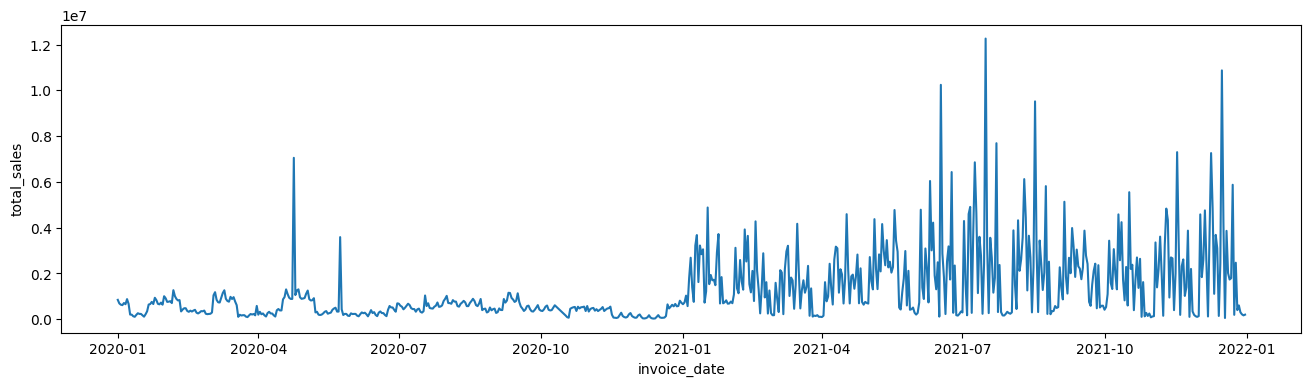

In [ ]:
plt.figure(figsize=(16, 4))
sns.lineplot(data=df.groupby('invoice_date')['total_sales'].sum())
plt.title('Распределение продаж по дням')

Text(0.5, 1.0, 'price_per_unit')

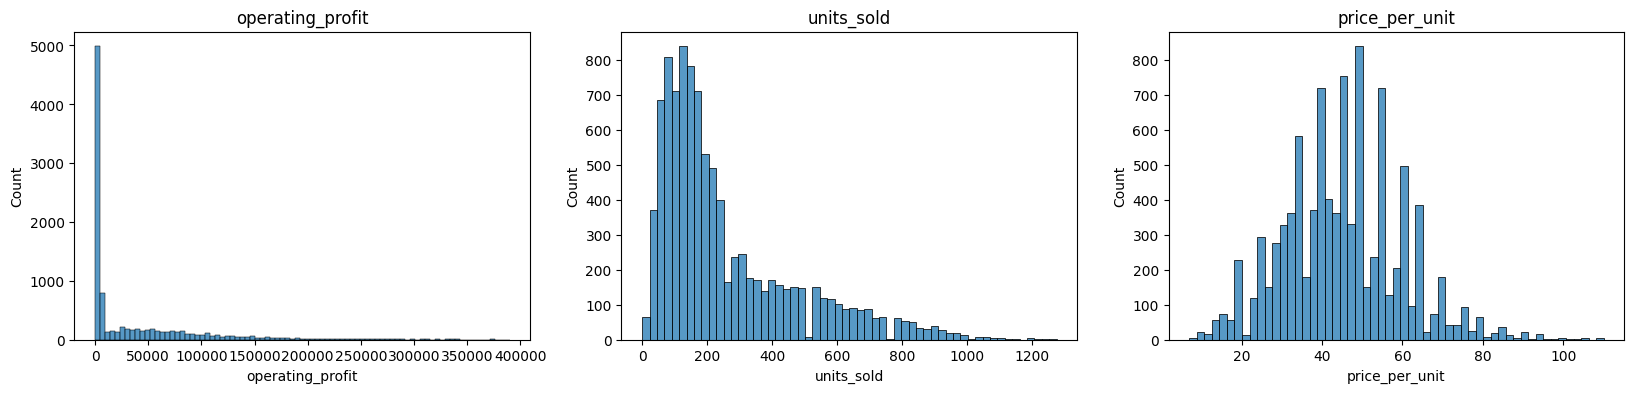

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(20, 4))

sns.histplot(df.operating_profit, ax=ax[0])
ax[0].set_title('operating_profit')

sns.histplot(df.units_sold, ax=ax[1])
ax[1].set_title('units_sold')

sns.histplot(df.price_per_unit, ax=ax[2])
ax[2].set_title('price_per_unit')

In [9]:
df[df.operating_profit == df.operating_profit.min()]

,retailer,retailer_id,invoice_date,region,state,city,product,price_per_unit,units_sold,total_sales,operating_profit,operating_margin,sales_method
1019,Foot Locker,1185732,2021-06-05,Midwest,Nebraska,Omaha,Women's Athletic Footwear,35,0.0,0.0,0.0,0.40,Outlet
1025,Foot Locker,1185732,2021-06-11,Midwest,Nebraska,Omaha,Women's Athletic Footwear,30,0.0,0.0,0.0,0.40,Outlet
4907,Foot Locker,1185732,2021-06-05,Midwest,Nebraska,Omaha,Women's Athletic Footwear,33,0.0,0.0,0.0,0.55,Online
4913,Foot Locker,1185732,2021-06-11,Midwest,Nebraska,Omaha,Women's Athletic Footwear,27,0.0,0.0,0.0,0.53,Online


In [10]:
def group_ax(group):
    fig, ax = plt.subplots(1, 5, figsize=(20, 4))
    ax[0].set_title(f'units_sold by {group}')
    sns.barplot(data=df.groupby(group).units_sold.sum().sort_values(ascending=False), ax=ax[0])
    ax[0].tick_params(axis='x', labelrotation=90)

    ax[1].set_title(f'average units_sold by {group}')
    sns.barplot(data=df.groupby(group).units_sold.mean().sort_values(ascending=False), ax=ax[1])
    ax[1].tick_params(axis='x', labelrotation=90)

    ax[2].set_title(f'total operating profit by {group}')
    sns.barplot(data=df.groupby(group).operating_profit.sum().sort_values(ascending=False), ax=ax[2])
    ax[2].tick_params(axis='x', labelrotation=90)

    ax[3].set_title(f'average operating profit by {group}')
    sns.barplot(data=df.groupby(group).operating_profit.mean().sort_values(ascending=False), ax=ax[3])
    ax[3].tick_params(axis='x', labelrotation=90)

    ax[4].set_title(f'operating margin by {group}')
    sns.barplot(data=df.groupby(group).operating_margin.mean().sort_values(ascending=False), ax=ax[4])
    ax[4].tick_params(axis='x', labelrotation=90)
    plt.tight_layout()

In [11]:
def group_ax_topk(group, k):
    fig, ax = plt.subplots(1, 5, figsize=(20, 4))
    ax[0].set_title(f'total units_sold by {group} (top{k})')
    sns.barplot(data=df.groupby(group).units_sold.sum().sort_values(ascending=False)[:k], ax=ax[0])
    ax[0].tick_params(axis='x', labelrotation=90)

    ax[1].set_title(f'average units_sold by {group} (top{k})')
    sns.barplot(data=df.groupby(group).units_sold.mean().sort_values(ascending=False)[:k], ax=ax[1])
    ax[1].tick_params(axis='x', labelrotation=90)

    ax[2].set_title(f'total operating profit by {group} (top{k})')
    sns.barplot(data=df.groupby(group).operating_profit.sum().sort_values(ascending=False)[:k], ax=ax[2])
    ax[2].tick_params(axis='x', labelrotation=90)

    ax[3].set_title(f'average operating profit by {group} (top{k})')
    sns.barplot(data=df.groupby(group).operating_profit.mean().sort_values(ascending=False)[:k], ax=ax[3])
    ax[3].tick_params(axis='x', labelrotation=90)

    ax[4].set_title(f'operating margin by {group} (top{k})')
    sns.barplot(data=df.groupby(group).operating_margin.mean().sort_values(ascending=False)[:k], ax=ax[4])
    ax[4].tick_params(axis='x', labelrotation=90)
    plt.tight_layout()

In [12]:
def heatmap_ax(group_1, group_2):
    fig, ax = plt.subplots(1, 5, figsize=(24, 4))

    sns.heatmap( 
        pd.pivot_table(data=df, index=group_1, columns=group_2, values='units_sold', aggfunc=pd.Series.sum),
        cmap='coolwarm',
        ax=ax[0]
    )
    ax[0].set_title(f'units_sold by ({group_1}, {group_2})')

    sns.heatmap( 
        pd.pivot_table(data=df, index=group_1, columns=group_2, values='units_sold', aggfunc=pd.Series.mean),
        cmap='coolwarm',
        ax=ax[1]
    )
    ax[1].set_title(f'average units_sold by ({group_1}, {group_2})')
    
    sns.heatmap( 
        pd.pivot_table(data=df, index=group_1, columns=group_2, values='operating_profit', aggfunc=pd.Series.sum),
        cmap='coolwarm',
        ax=ax[2]
    )
    ax[2].set_title(f'total operating profit by ({group_1}, {group_2})')
    
    sns.heatmap( 
        pd.pivot_table(data=df, index=group_1, columns=group_2, values='operating_profit', aggfunc=pd.Series.mean),
        cmap='coolwarm',
        ax=ax[3]
    )
    ax[3].set_title(f'average operating profit by ({group_1}, {group_2})')

    sns.heatmap( 
        pd.pivot_table(data=df, index=group_1, columns=group_2, values='operating_margin', aggfunc=pd.Series.mean),
        annot=True,
        cmap='coolwarm',
        ax=ax[4]
    )
    ax[4].set_title(f'average operating margin by ({group_1}, {group_2})')
    plt.tight_layout()

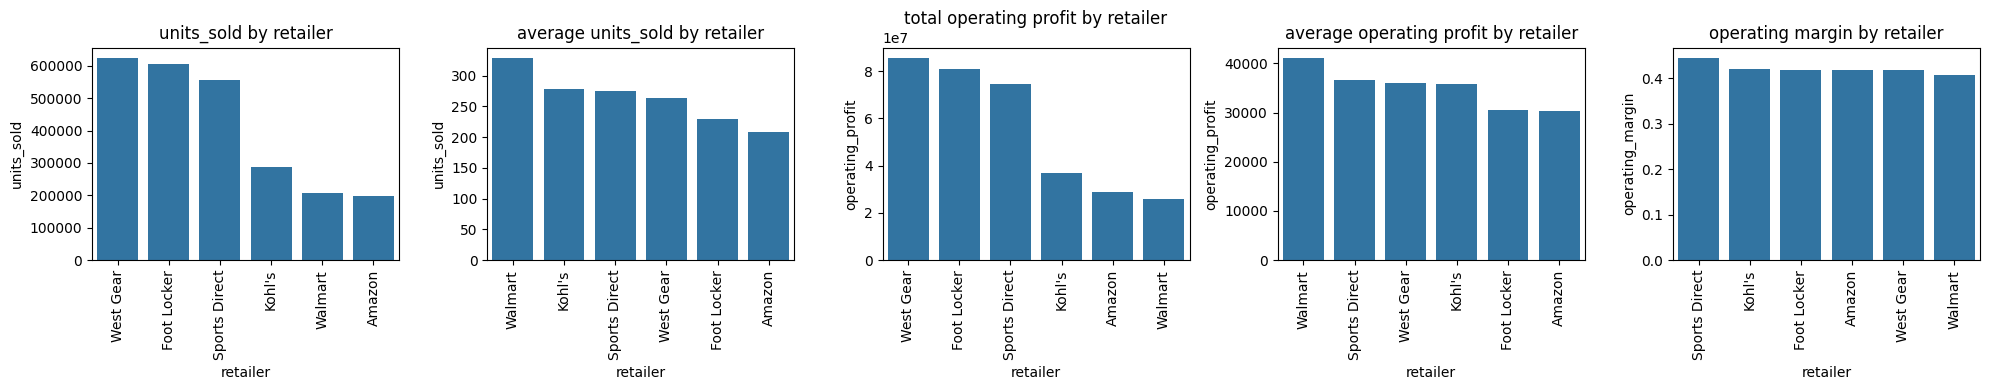

In [13]:
group_ax('retailer')

In [14]:
df[df.retailer == 'West Gear'].invoice_date.min(), df[df.retailer == 'Walmart'].invoice_date.min(), 

(Timestamp('2020-01-02 00:00:00'), Timestamp('2020-04-17 00:00:00'))

In [15]:
df[df.retailer == 'West Gear'].city.nunique(), df[df.retailer == 'Foot Locker'].city.nunique(), df[df.retailer == 'Sports Direct'].city.nunique(), df[df.retailer == 'Walmart'].city.nunique(), 

(23, 32, 26, 6)

По общему кол-ву проданных товаров и операционной прибыли лидером является ретейлеры "West Gear", "Foot Locker" и "Sports Direct", но по средним значениям лидирует "Walmart". Причиной этому является то, что география Walmart, продающих продукцию adidas охватывает значительно меньше городов, но тк магази популярен, то и средние продажи выше.

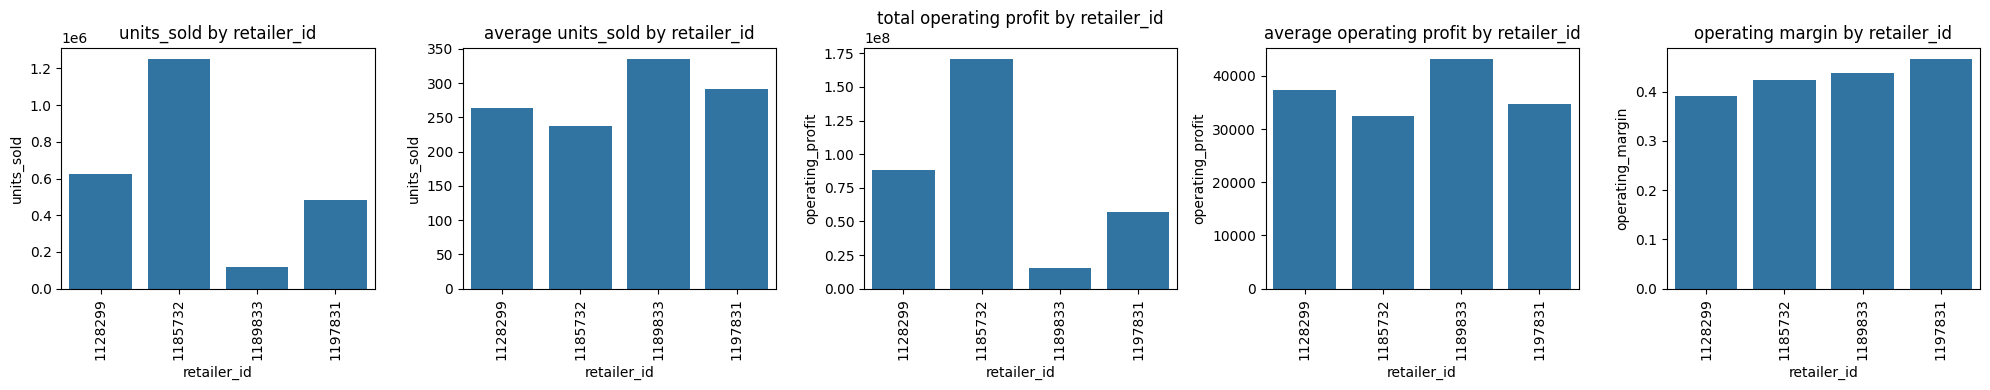

In [16]:
group_ax('retailer_id')

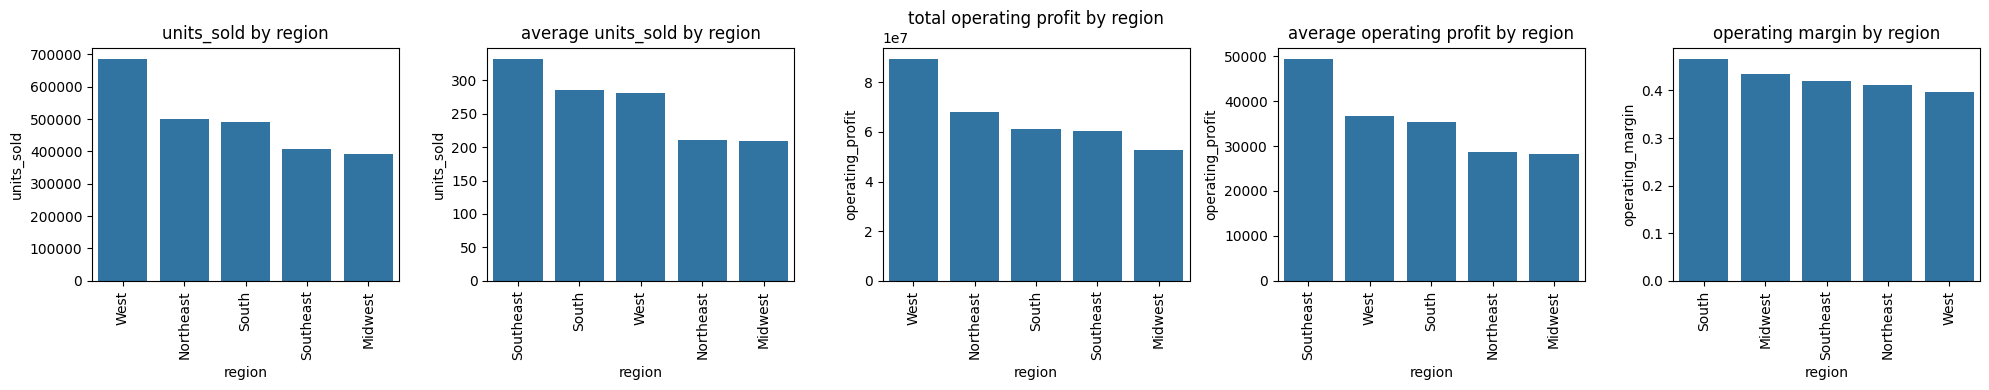

In [17]:
group_ax('region')

Т.к. регион West самый большой, то в абсолютных значениях он лидирует. В средних же значених юго-восток на первом месте.

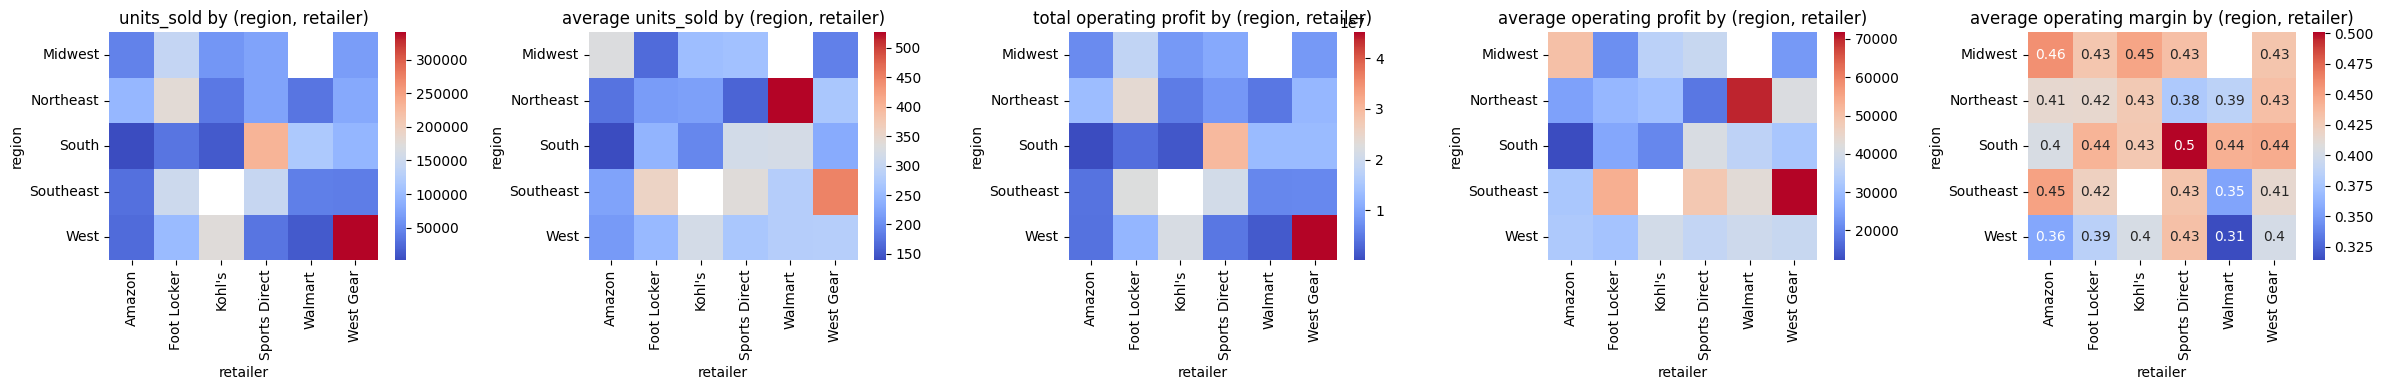

In [18]:
heatmap_ax('region', 'retailer')

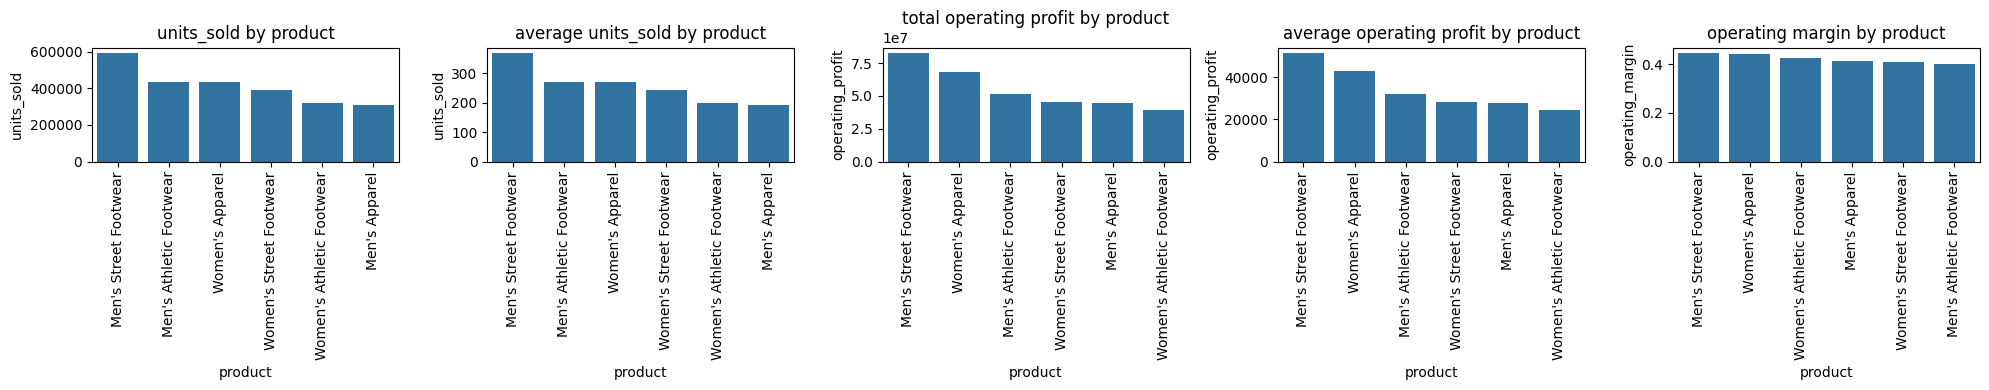

In [19]:
group_ax('product')

Мужская обувь продается лучше. Ниже данные в разбивке по региону.

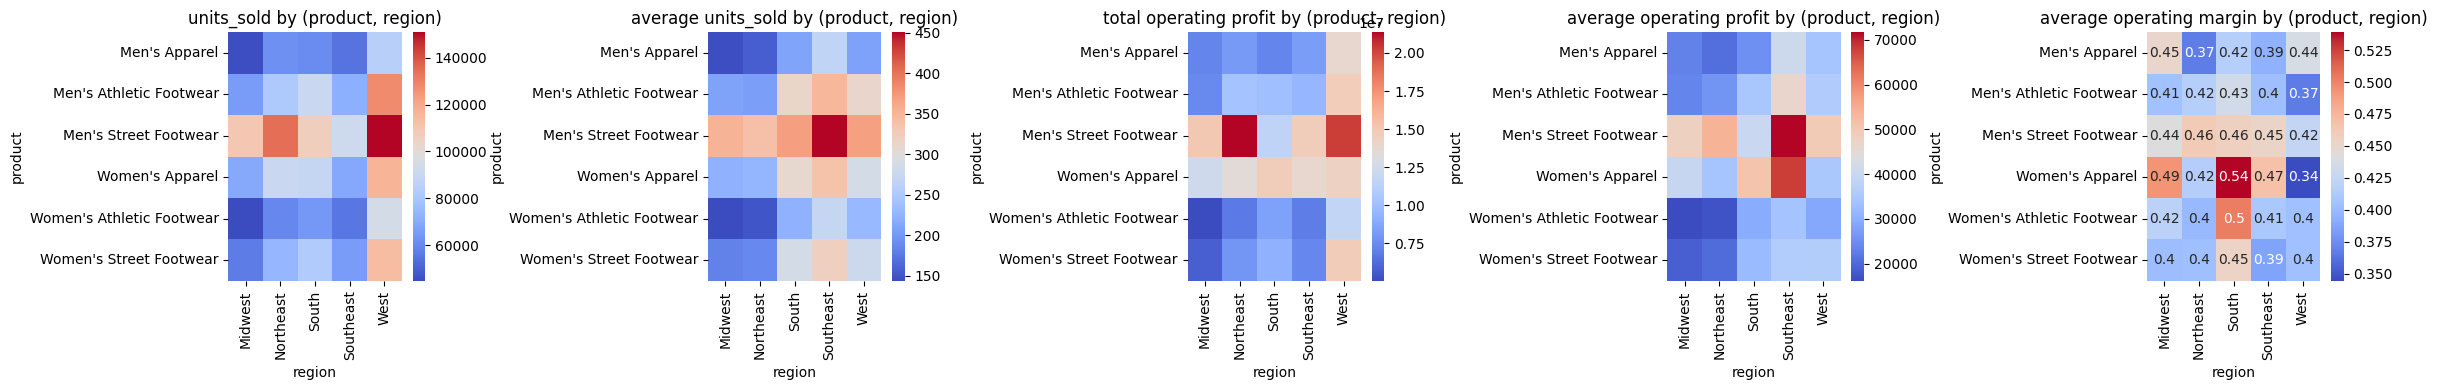

In [20]:
heatmap_ax('product', 'region')

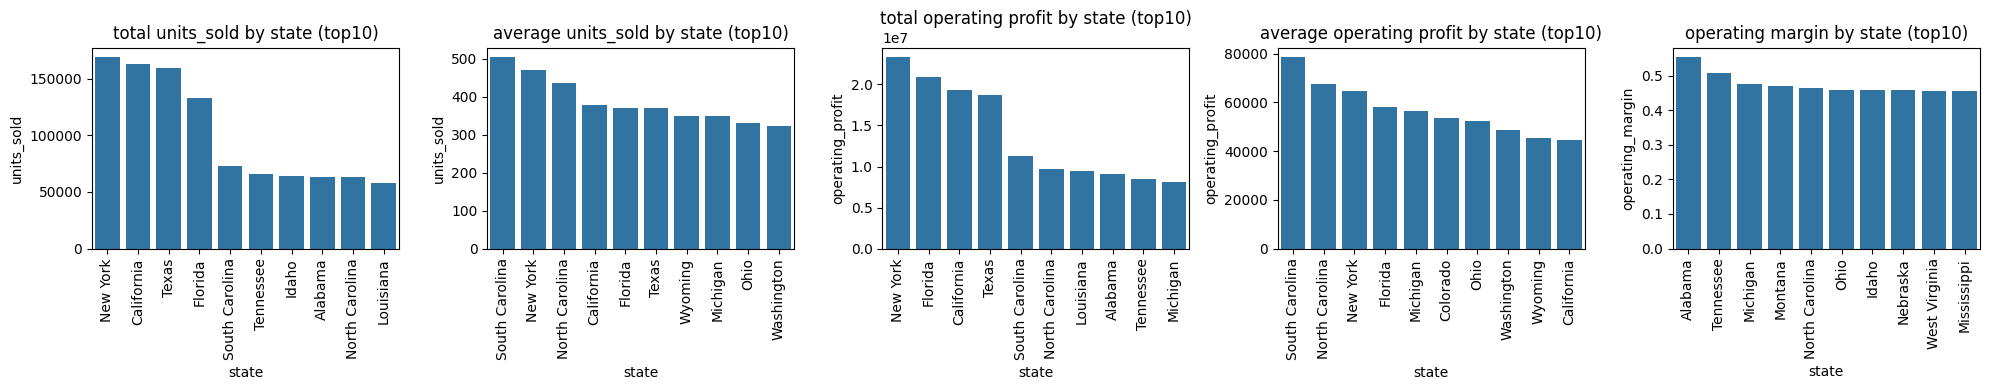

In [21]:
group_ax_topk('state', 10)

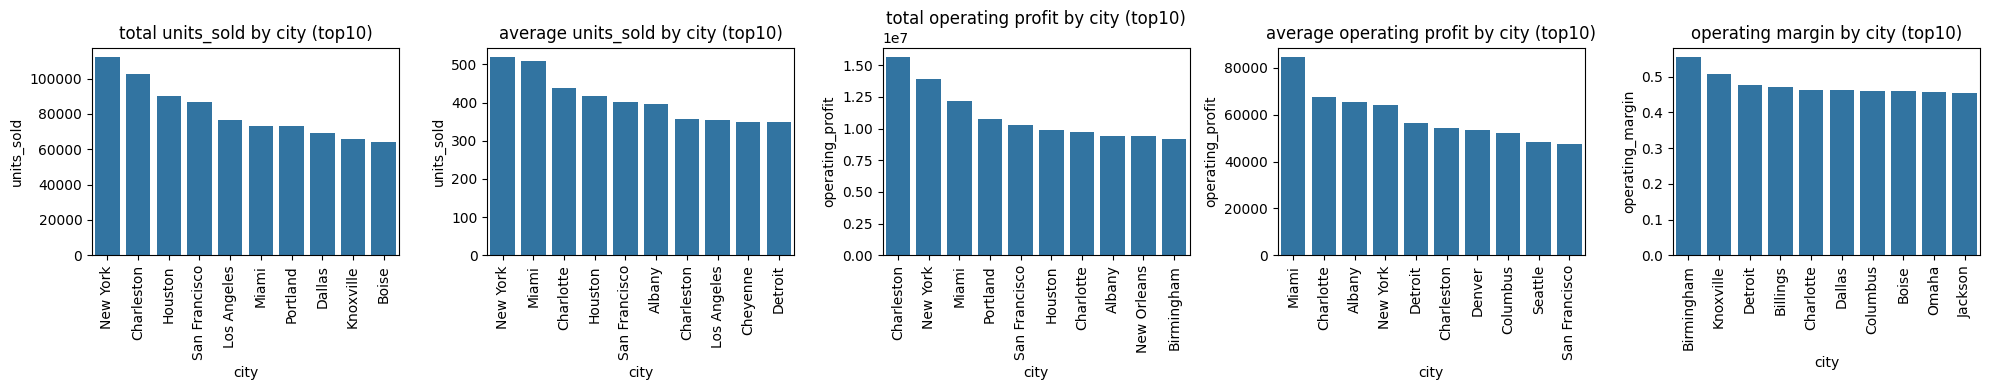

In [22]:
group_ax_topk('city', 10)

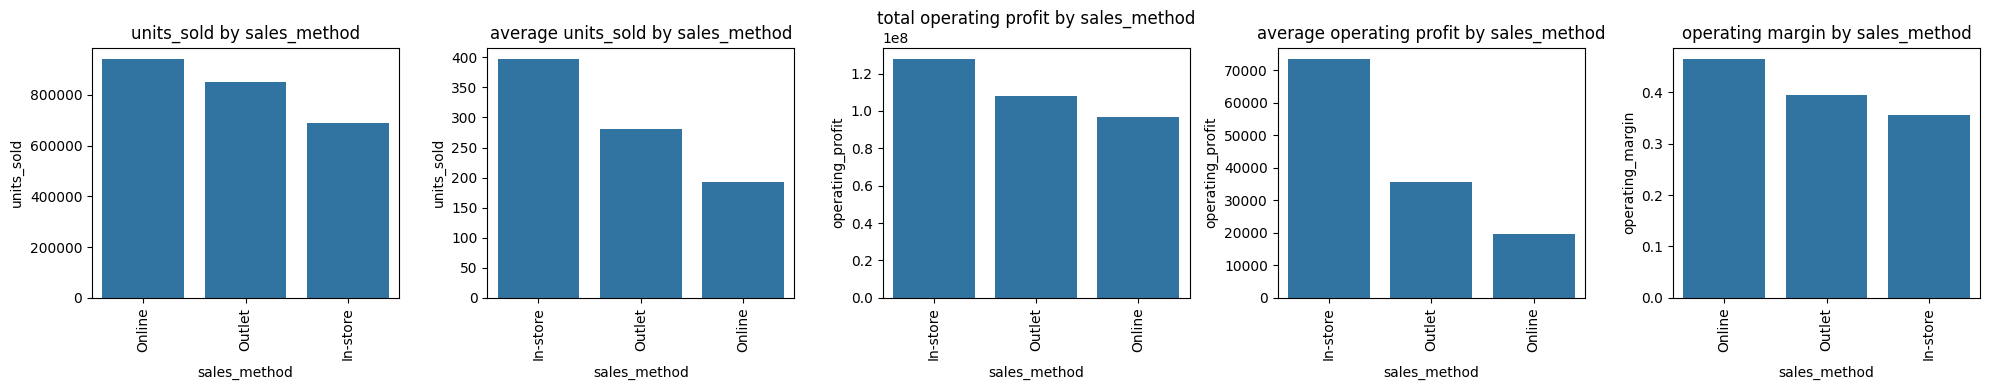

In [23]:
group_ax('sales_method')

<Axes: xlabel='units_sold', ylabel='Density'>

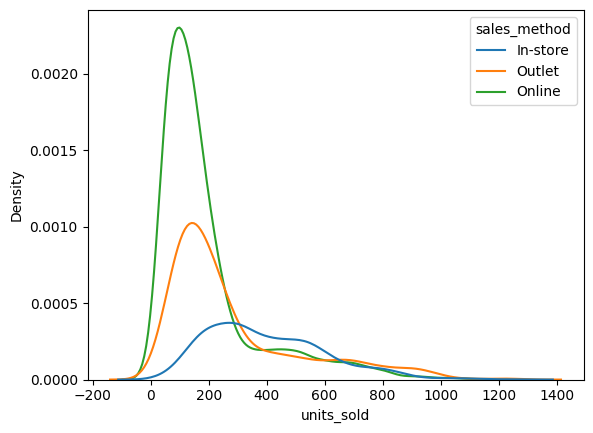

In [24]:
sns.kdeplot(df, x='units_sold', hue='sales_method')

Видно, что онлайн находится на первом месте по продажам единиц товаров, но при этом, среднее кол-во проданных вещей выше в рознице.

In [25]:
df['sex'] = df['product'].str.startswith('M')
df['sex'] = df['sex'].apply(lambda x: 'male' if x else 'female')

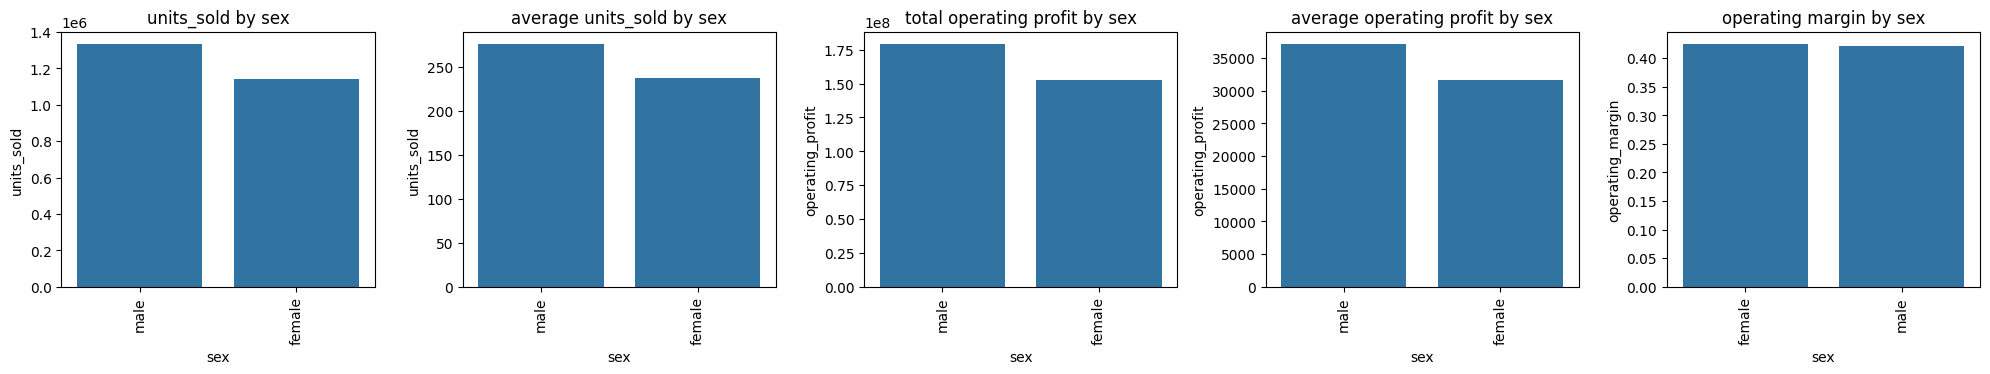

In [26]:
group_ax('sex')

Проверим гипотезу о том, что мужчины больше заинтересованы в продукции помпании, что сказывается на операционной прибыли.

H0: $\mu_{operating\_profit\_male} = \mu_{operating\_profit\_female}$

H1: $\neq$

<Axes: xlabel='operating_profit', ylabel='Density'>

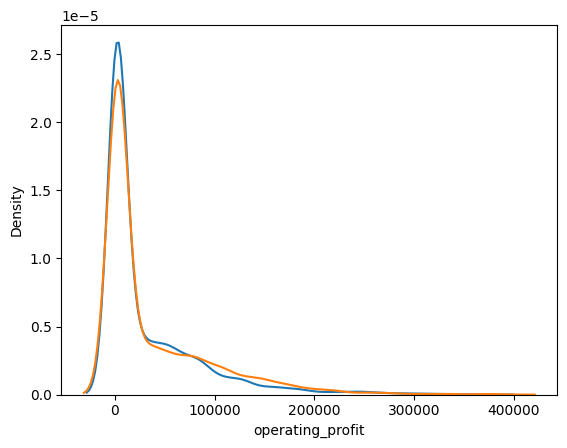

In [27]:
sns.kdeplot(df[df['sex'] == 'female'].operating_profit)
sns.kdeplot(df[df['sex'] == 'male'].operating_profit)

Проверять буду бутстрапом по причине скошенных распределений (тяжелого хвоста)

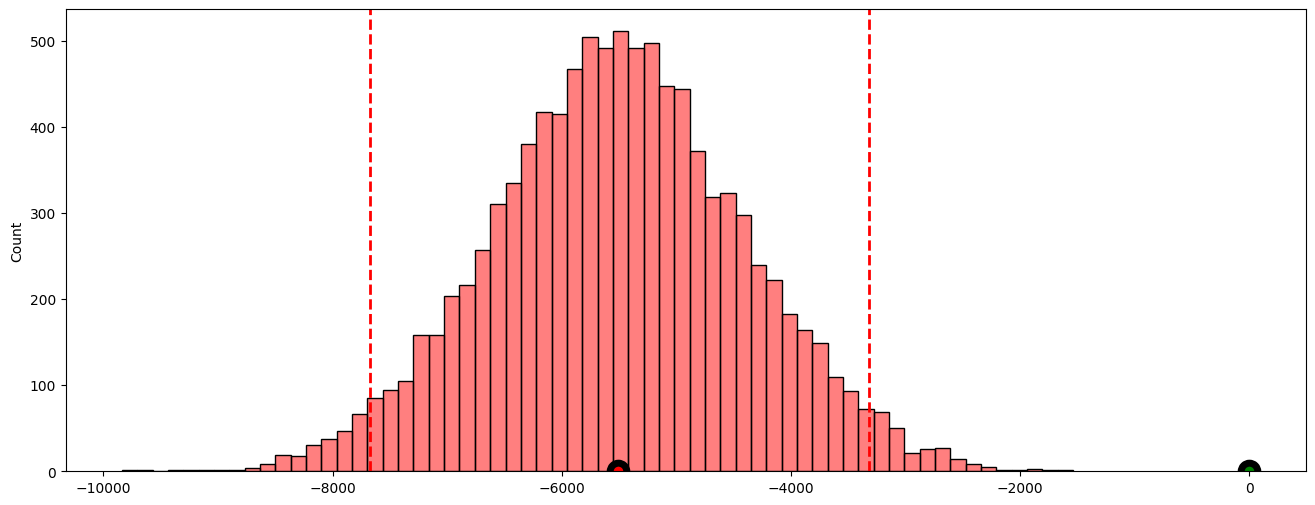

In [28]:
n=10000
alpha = 0.05
p1 = df[df['sex'] == 'female'].operating_profit
p2 = df[df['sex'] == 'male'].operating_profit
res = []

for i in range(n):
    res.append(
        (np.random.choice(p1, size=p1.shape[0], replace=True).mean()) -
        (np.random.choice(p2, size=p2.shape[0], replace=True).mean())
    )

fig = plt.figure(figsize=(16, 6))
sns.histplot(res, color='r', alpha=0.5)
plt.plot(np.mean(res), 0, 'ro', markersize=12, markeredgecolor='black', markeredgewidth=5)
plt.plot(0, 0, 'go', markersize=12, markeredgecolor='black', markeredgewidth=5)
plt.axvline(x=np.quantile(res, alpha/2), color='r', linestyle='--', linewidth=2)
plt.axvline(x=np.quantile(res, 1-alpha/2), color='r', linestyle='--', linewidth=2)

Различия статзначимые, т.к. ноль не попал в доверительный интервал. Возможно, аномалии утянули среднее. Обрежем по 95% квантилю и посмотрим.

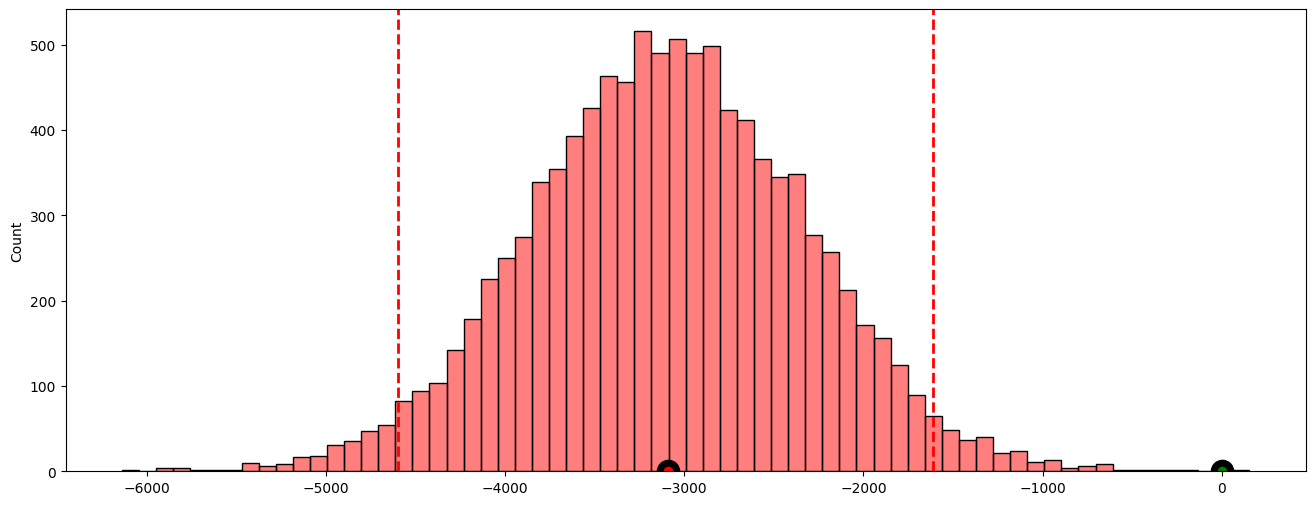

In [29]:
tmp = df[df.operating_profit < df.operating_profit.quantile(0.95)]

n=10000
alpha = 0.05
p1 = tmp[tmp['sex'] == 'female'].operating_profit
p2 = tmp[tmp['sex'] == 'male'].operating_profit
res = []

for i in range(n):
    res.append(
        (np.random.choice(p1, size=p1.shape[0], replace=True).mean()) -
        (np.random.choice(p2, size=p2.shape[0], replace=True).mean())
    )

fig = plt.figure(figsize=(16, 6))
sns.histplot(res, color='r', alpha=0.5)
plt.plot(np.mean(res), 0, 'ro', markersize=12, markeredgecolor='black', markeredgewidth=5)
plt.plot(0, 0, 'go', markersize=12, markeredgecolor='black', markeredgewidth=5)
plt.axvline(x=np.quantile(res, alpha/2), color='r', linestyle='--', linewidth=2)
plt.axvline(x=np.quantile(res, 1-alpha/2), color='r', linestyle='--', linewidth=2)

Статзначимые.

Построим тепловую карту по полу и региону, чтобы понять какого-пола пользователи наиболее активны в каждом из регионов.

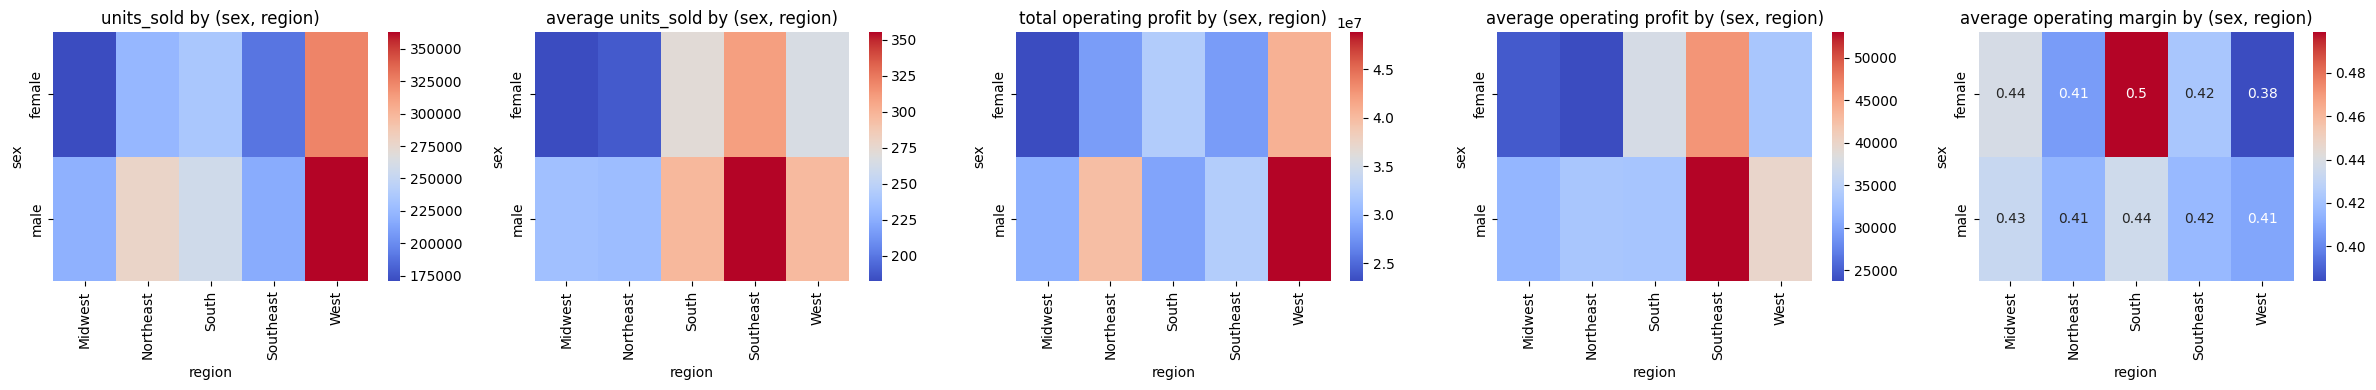

In [30]:
heatmap_ax('sex', 'region')

Мужчины приносят большу прибыль (как в средних значениях так и в абсолютных) практически во всех регионах, кроме юга. Операционная прибыль (средняя и абсолютная) в южных регионах выше у женщин. Проверим эту гипотезу:

<Axes: xlabel='operating_profit', ylabel='Density'>

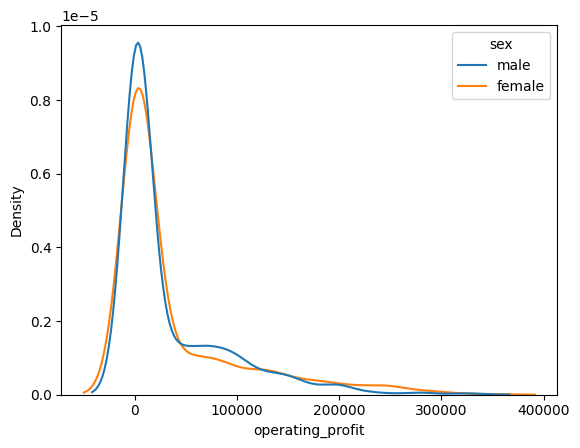

In [31]:
tmp = df[df.region == 'South']
sns.kdeplot(tmp, x='operating_profit', hue='sex')

In [32]:
tmp.groupby('sex').operating_profit.mean()

sex
female    37491.366771
male      33270.212014
Name: operating_profit, dtype: float64

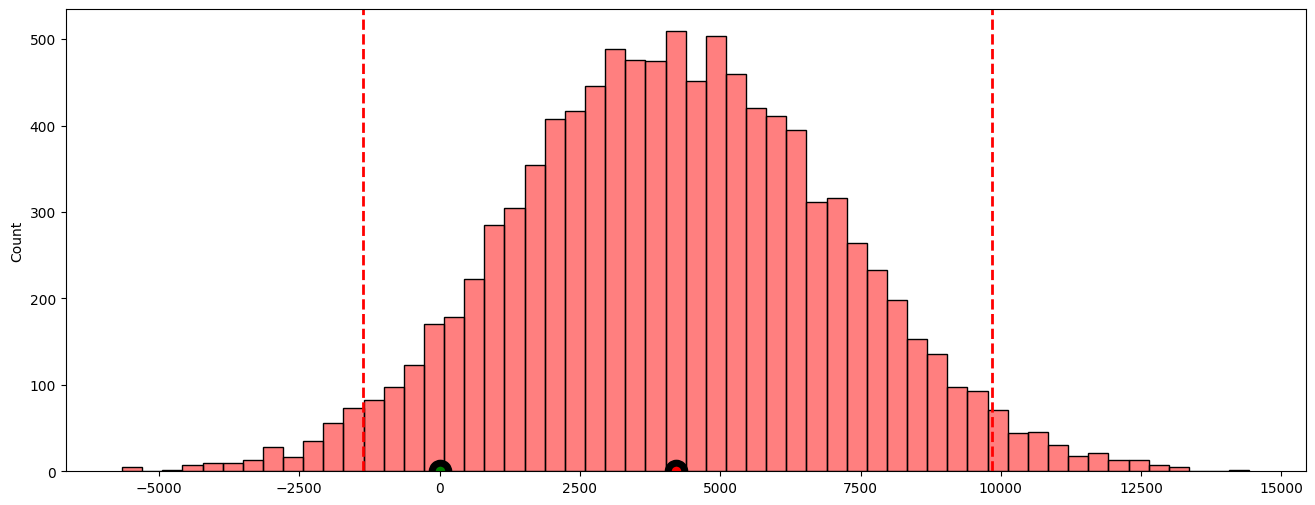

In [33]:
n=10000
alpha = 0.05
p1 = tmp[tmp['sex'] == 'female'].operating_profit
p2 = tmp[tmp['sex'] == 'male'].operating_profit
res = []

for i in range(n):
    res.append(
        (np.random.choice(p1, size=p1.shape[0], replace=True).mean()) -
        (np.random.choice(p2, size=p2.shape[0], replace=True).mean())
    )

fig = plt.figure(figsize=(16, 6))
sns.histplot(res, color='r', alpha=0.5)
plt.plot(np.mean(res), 0, 'ro', markersize=12, markeredgecolor='black', markeredgewidth=5)
plt.plot(0, 0, 'go', markersize=12, markeredgecolor='black', markeredgewidth=5)
plt.axvline(x=np.quantile(res, alpha/2), color='r', linestyle='--', linewidth=2)
plt.axvline(x=np.quantile(res, 1-alpha/2), color='r', linestyle='--', linewidth=2)

Имеющиеся данные не позволяют отвергнуть нулевую гипотезу о равенстве средних.

In [34]:
df['quarter'] = df.invoice_date.dt.quarter
df['weekend'] = df.invoice_date.dt.weekday >= 5
df['year'] = df.invoice_date.dt.year

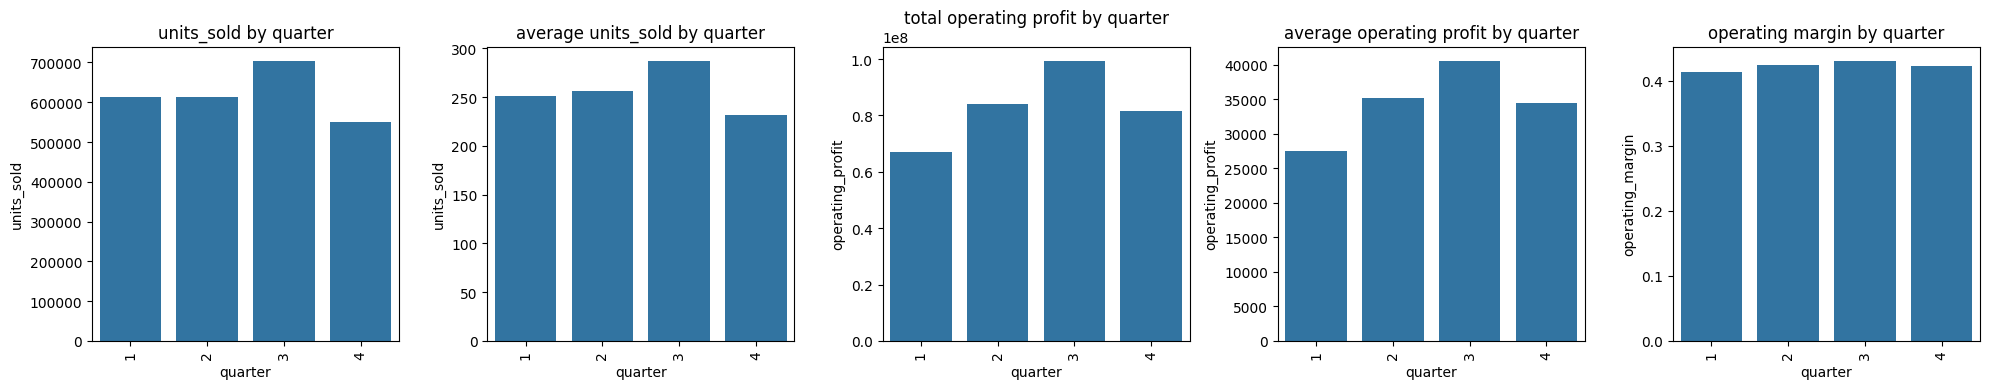

In [35]:
group_ax('quarter')

Лучшее время года по продажам и выручке - осень.

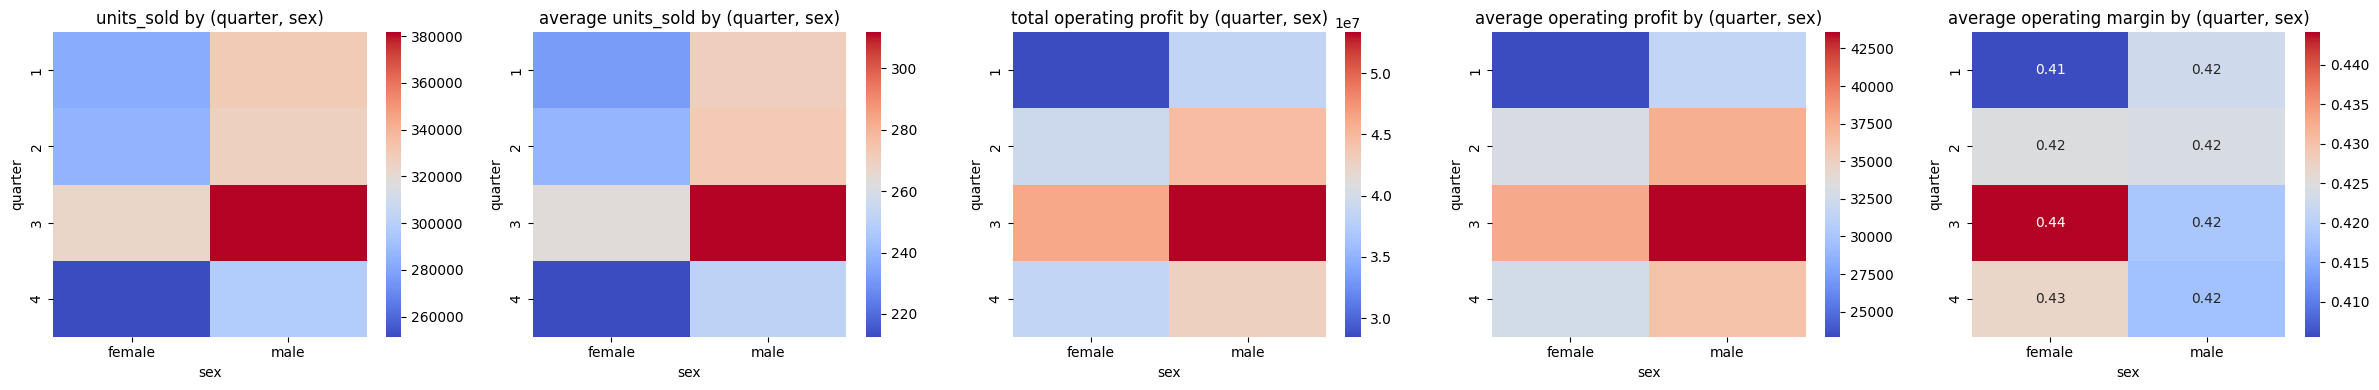

In [36]:
heatmap_ax('quarter', 'sex')

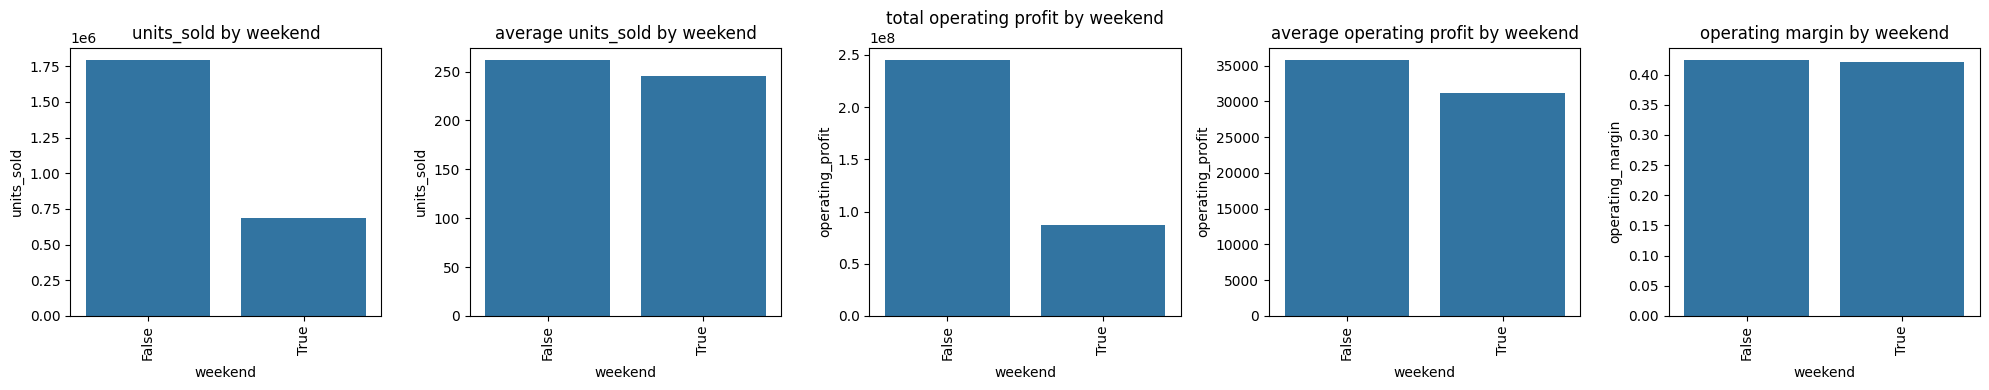

In [37]:
group_ax('weekend')

Видно, что основные продажи приходятся на будние дни. Проверим, статзначимы ли различия в операционной прибыли между выходными и будними днями.

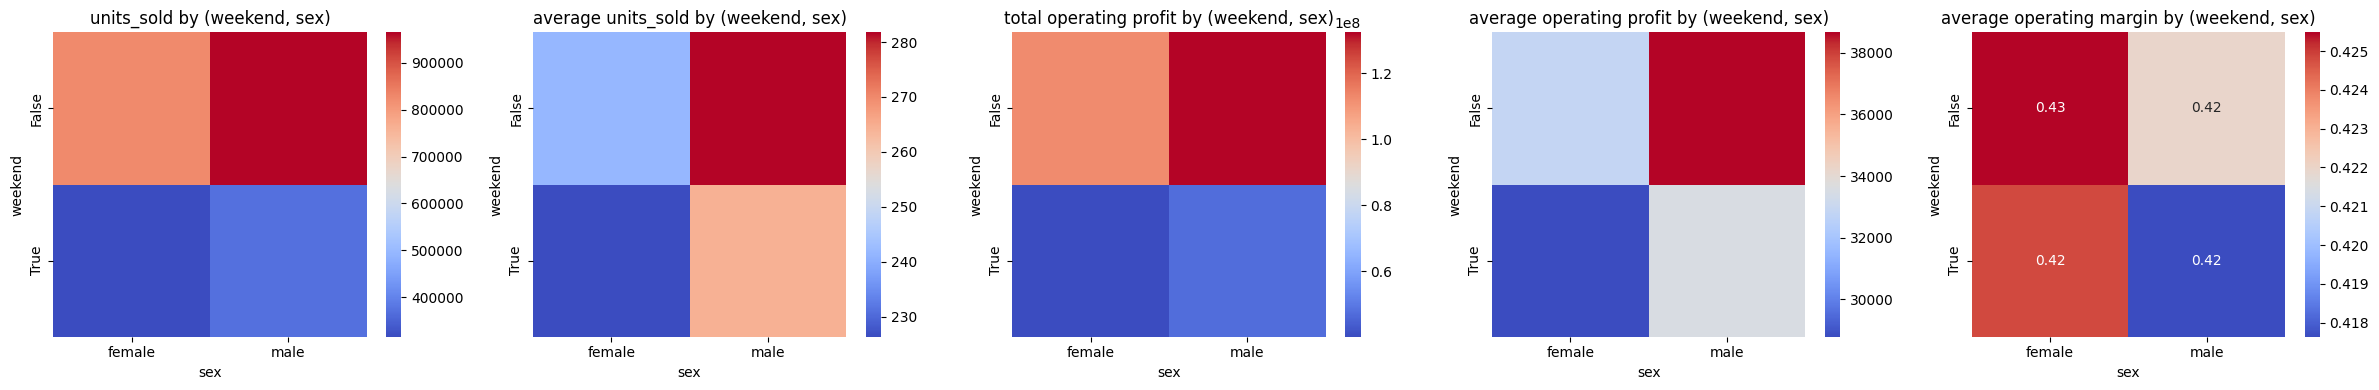

In [38]:
heatmap_ax('weekend', 'sex')

<Axes: xlabel='operating_profit', ylabel='Density'>

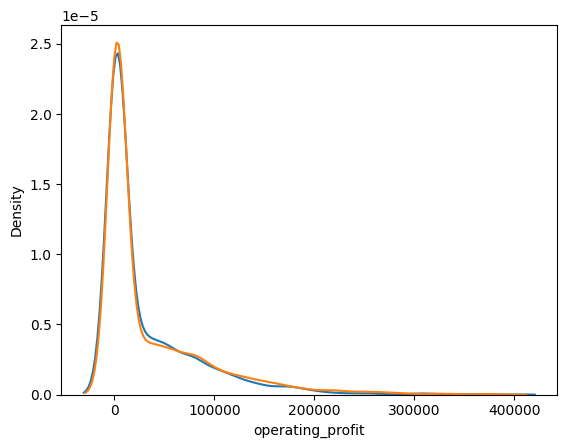

In [39]:
sns.kdeplot(df[df.weekend == True].operating_profit)
sns.kdeplot(df[df.weekend == False].operating_profit)

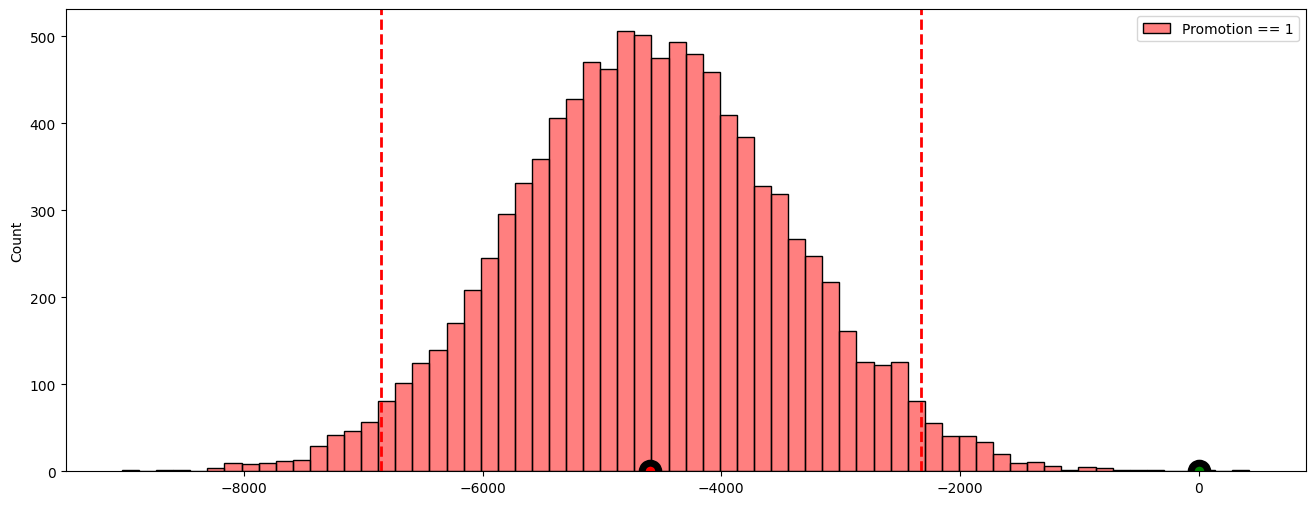

In [40]:
n=10000
alpha = 0.05
p1 = df[df['weekend'] == True].operating_profit
p2 = df[df['weekend'] == False].operating_profit
res = []

for i in range(n):
    res.append(
        (np.random.choice(p1, size=p1.shape[0], replace=True).mean()) -
        (np.random.choice(p2, size=p2.shape[0], replace=True).mean())
    )

fig = plt.figure(figsize=(16, 6))
sns.histplot(res, color='r', alpha=0.5, label='Promotion == 1')
plt.plot(np.mean(res), 0, 'ro', markersize=12, markeredgecolor='black', markeredgewidth=5)
plt.plot(0, 0, 'go', markersize=12, markeredgecolor='black', markeredgewidth=5)
plt.axvline(x=np.quantile(res, alpha/2), color='r', linestyle='--', linewidth=2)
plt.axvline(x=np.quantile(res, 1-alpha/2), color='r', linestyle='--', linewidth=2)
plt.legend()

Средняя операционная прибыль статзначимо выше в будние дни.

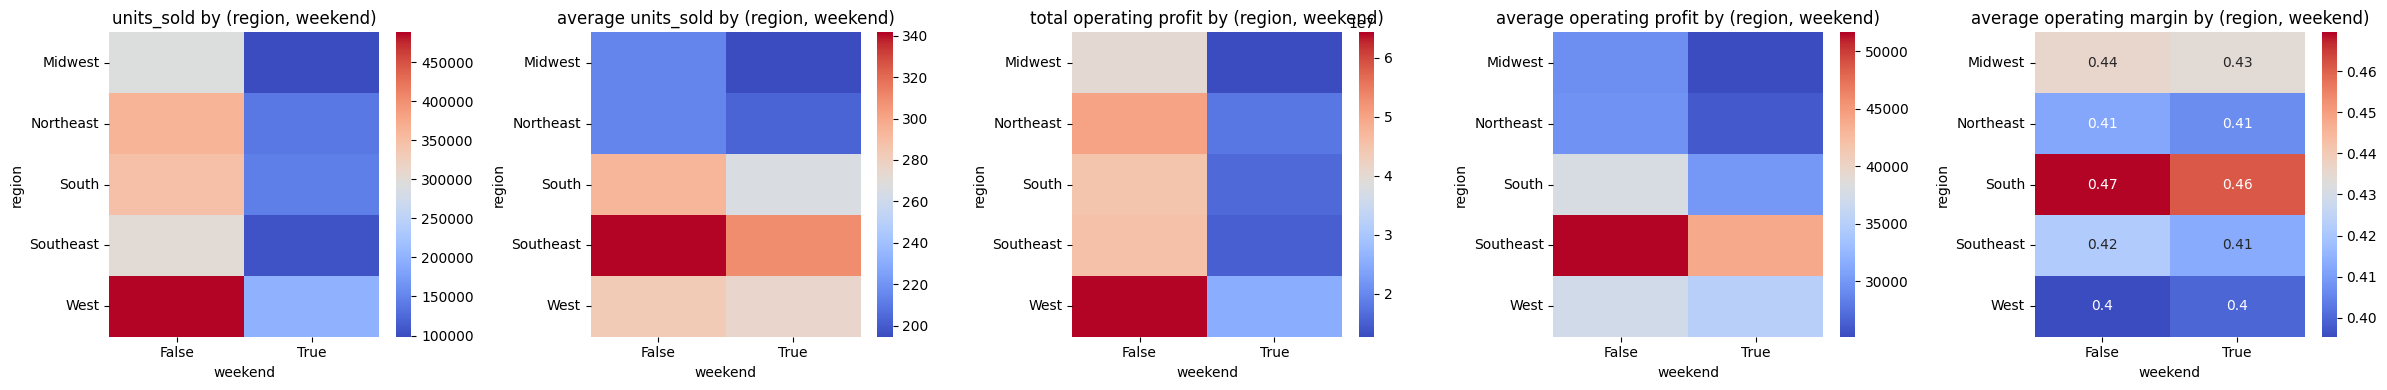

In [41]:
heatmap_ax('region', 'weekend')

In [42]:
df['dow'] = df.invoice_date.dt.strftime("%a")

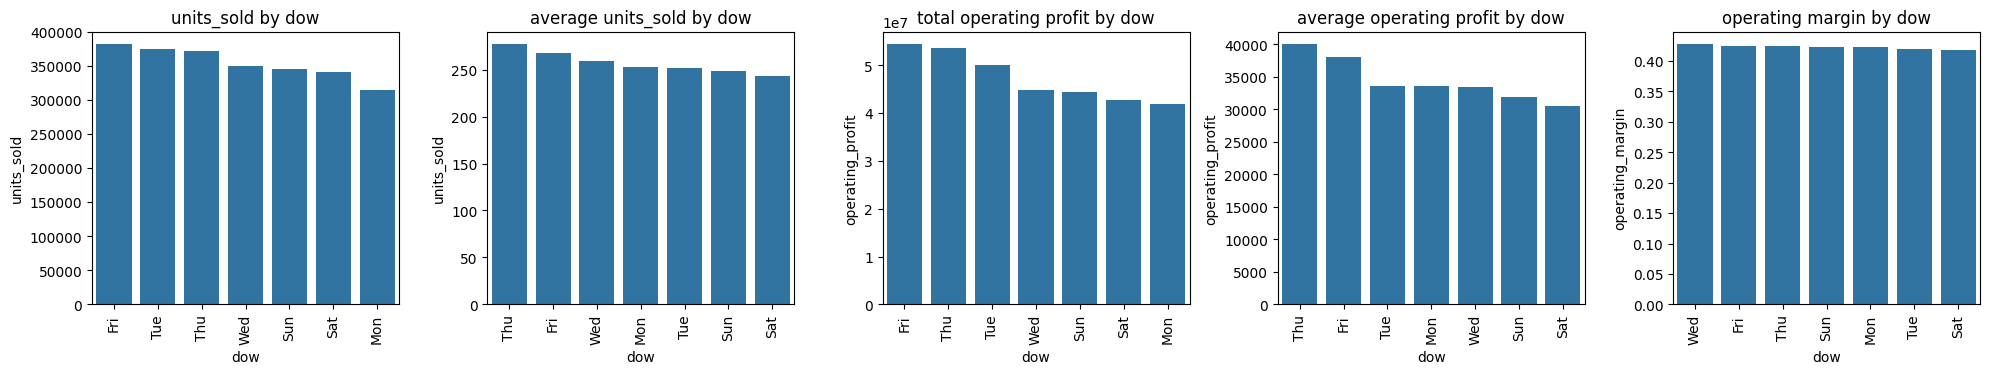

In [43]:
group_ax('dow')

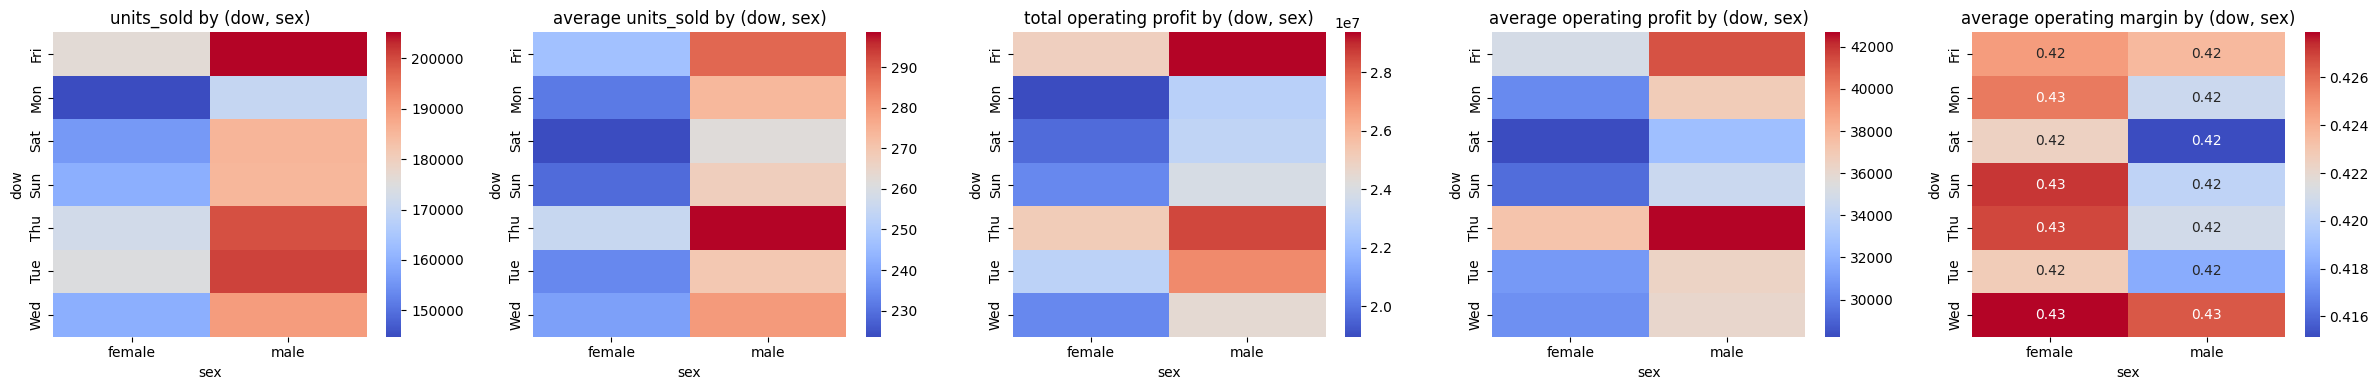

In [44]:
heatmap_ax('dow', 'sex')

Проверим, есть ли зависимость между днем недели и средней операционной прибылью.

<Axes: xlabel='operating_profit', ylabel='Density'>

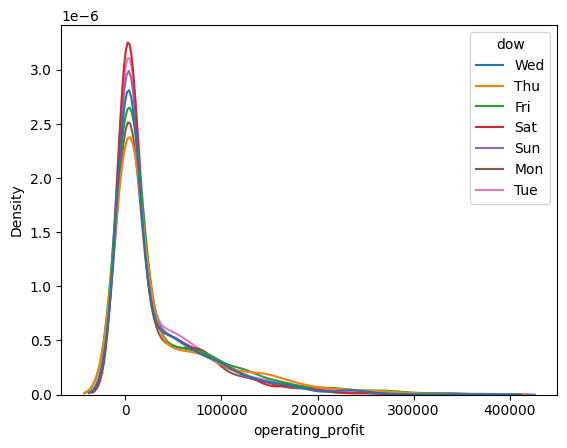

In [45]:
sns.kdeplot(data=df, x='operating_profit', hue='dow')

Воспользуемся ANOVA. При большом кол-ве данных метод устойчив к невыполнению условия нормальности данных, а гомоскедастичность проверим тестом Левена.

In [46]:
pg.homoscedasticity(data=df, group='dow', dv='operating_profit')

,W,pval,equal_var
levene,4.988956,0.000041,False


Дисперсии отличаются, поэтому воспльзуемся ANOVA Welch, который используется в таких случаях.

In [48]:
pg.welch_anova(data=df, dv='operating_profit', between='dow')

,Source,ddof1,ddof2,F,p-unc,np2
0,dow,6,4265.451258,4.981425,0.000043,0.003352


p-value < 0.05. Какие-то группы отличаются между собой.

In [49]:
pg.pairwise_tukey(data=df, dv='operating_profit', between='dow')

,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,Fri,Mon,38117.907910,33581.277432,4536.630478,2098.696487,2.161642,0.316729,0.079930
1,Fri,Sat,38117.907910,30452.657697,7665.250213,2033.605315,3.769291,0.003128,0.141082
2,Fri,Sun,38117.907910,31912.287899,6205.620011,2039.855270,3.042186,0.038023,0.111448
3,Fri,Thu,38117.907910,39967.189724,-1849.281814,2057.850882,-0.898647,0.972872,-0.030600
4,Fri,Tue,38117.907910,33653.909752,4463.998159,2004.892335,2.226553,0.281180,0.079112
5,Fri,Wed,38117.907910,33366.361218,4751.546692,2056.669525,2.310311,0.238951,0.084740
6,Mon,Sat,33581.277432,30452.657697,3128.619735,2105.293976,1.486073,0.753325,0.062007
7,Mon,Sun,33581.277432,31912.287899,1668.989533,2111.331729,0.790491,0.985944,0.032109
8,Mon,Thu,33581.277432,39967.189724,-6385.912293,2128.723185,-2.999879,0.043113,-0.111422
9,Mon,Tue,33581.277432,33653.909752,-72.632320,2077.572001,-0.034960,1.000000,-0.001371


Видно, что средняя операционная прибыль в черверг значимо выше чем во всех днях недели за исключением пятницы. А в пятницу выше субботы и воскресенья.

В ходе анализа датасета продаж Adidas было показано, что выручка распределена неравномерно как по регионам, так и по ритейлерам: основной вклад формируют несколько ключевых регионов и крупных продавцов. Анализ по категориям товаров выявил различия в объёмах продаж и прибыли, что указывает на разную коммерческую эффективность продуктовых групп. Также было установлено, что каналы продаж (онлайн и офлайн) отличаются по уровню выручки и могут по-разному влиять на итоговые показатели.

Дополнительно анализ временной динамики показал колебания продаж, что может свидетельствовать о наличии сезонных эффектов. В целом, работа позволила выделить ключевые драйверы выручки (регион, ритейлер, категория, канал), однако выводы носят описательный характер и не учитывают внешние факторы, поэтому не позволяют делать причинно-следственные заключения.